# EDA: Generated Code Dataset

Exploratory analysis of LLM-generated code across **models** (GPT, Claude, Gemini) and **languages** (Python, JavaScript, Java, C, SQL).

1. Basic summary statistics
2. Distribution of code across models and languages
3. Code length analysis
4. Keyword frequency and patterns

## Setup and build dataset

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Project root (works when notebook is in project root or in notebooks/)
ROOT = Path(".").resolve()
if not (ROOT / "python").exists() and (ROOT.parent / "python").exists():
    ROOT = ROOT.parent

print(f"Project root: {ROOT}")

Project root: /Users/priyankaramachandran/Desktop/UCD Courses/SWE/LLMs-for-CWE


In [2]:
# Extensions per language
LANG_EXT = {
    "python": ".py",
    "javascript": ".js",
    "java": ".java",
    "c": ".c",
    "sql": ".sql",
}

rows = []
for lang, ext in LANG_EXT.items():
    lang_dir = ROOT / lang
    if not lang_dir.exists():
        continue
    for model_dir in lang_dir.iterdir():
        if not model_dir.is_dir():
            continue
        model = model_dir.name
        for f in model_dir.glob(f"*{ext}"):
            path = f.relative_to(ROOT)
            prompt_id = f.stem
            try:
                text = f.read_text(encoding="utf-8", errors="replace")
            except Exception:
                text = ""
            n_lines = len(text.splitlines())
            rows.append({
                "language": lang,
                "model": model,
                "prompt_id": prompt_id,
                "path": str(path),
                "n_chars": len(text),
                "n_lines": n_lines,
                "content": text,
            })

df = pd.DataFrame(rows)
print(f"Total files: {len(df)}")
df.head()

Total files: 1452


,language,model,prompt_id,path,n_chars,n_lines,content
0,python,gemini,p106,python/gemini/p106.py,285,13,"import os\n\nfilename = ""secret_python.txt""\ns..."
1,python,gemini,p5,python/gemini/p5.py,222,11,"import sys\n\ndata = [""A"", ""B"", ""C""]\ntry:\n ..."
2,python,gemini,p102,python/gemini/p102.py,249,12,"import os\n\nfilename = ""important_config""\nda..."
3,python,gemini,p88,python/gemini/p88.py,631,25,"from flask import Flask, request\nimport yaml\..."
4,python,gemini,p1,python/gemini/p1.py,115,3,"def copy_bytes(dest, src, n):\n # In Python..."


## 1. Basic summary statistics

Total samples per model and language; average code length (characters and lines).

In [3]:
print("Samples per model:")
print(df.groupby("model").size())
print("\nSamples per language:")
print(df.groupby("language").size())
print("\nAvg characters per model:")
print(df.groupby("model")["n_chars"].agg(["mean", "count"]).round(1))
print("\nAvg characters per language:")
print(df.groupby("language")["n_chars"].agg(["mean", "count"]).round(1))
print("\nAvg lines per model:")
print(df.groupby("model")["n_lines"].agg(["mean", "count"]).round(1))
print("\nAvg lines per language:")
print(df.groupby("language")["n_lines"].agg(["mean", "count"]).round(1))

Samples per model:
model
claude    386
gemini    455
gpt       611
dtype: int64

Samples per language:
language
c             291
java          365
javascript    353
python        359
sql            84
dtype: int64

Avg characters per model:
          mean  count
model                
claude  1568.6    386
gemini   338.5    455
gpt      907.3    611

Avg characters per language:
              mean  count
language                 
c            889.2    291
java        1354.3    365
javascript   700.1    353
python       706.5    359
sql          715.4     84

Avg lines per model:
        mean  count
model              
claude  48.3    386
gemini  12.5    455
gpt     29.6    611

Avg lines per language:
            mean  count
language               
c           33.5    291
java        35.7    365
javascript  24.0    353
python      25.6    359
sql         23.5     84


## 2. Distribution across models and languages

### 2A. Table: number of samples by model and language

In [4]:
table = pd.crosstab(df["model"], df["language"], margins=True, margins_name="Total")
table.index = table.index.str.replace("gpt", "GPT").str.replace("claude", "Claude Sonnet").str.replace("gemini", "Gemini")
table

language,c,java,javascript,python,sql,Total
model,,,,,,
Claude Sonnet,93,94,94,95,10,386
Gemini,86,111,112,115,31,455
GPT,112,160,147,149,43,611
Total,291,365,353,359,84,1452


### 2B. Bar chart: number of samples by language

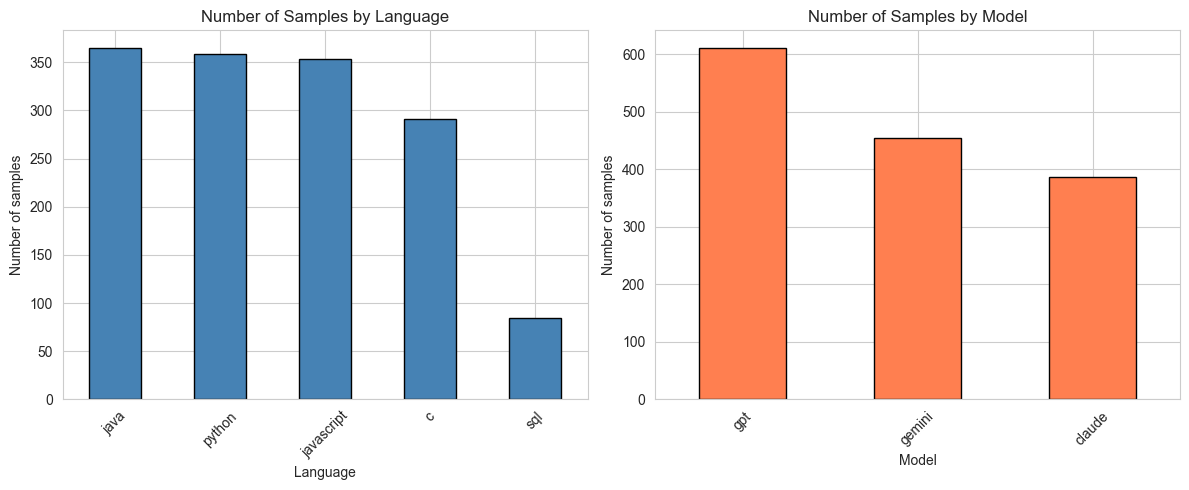

In [5]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

count_by_lang = df.groupby("language").size().sort_values(ascending=False)
count_by_lang.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Number of Samples by Language")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis="x", rotation=45)

count_by_model = df.groupby("model").size().sort_values(ascending=False)
count_by_model.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Number of Samples by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Number of samples")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3. Code length analysis

### 3A. Average code length by language

            avg_chars  avg_lines
language                        
c               889.2       33.5
java           1354.3       35.7
javascript      700.1       24.0
python          706.5       25.6
sql             715.4       23.5


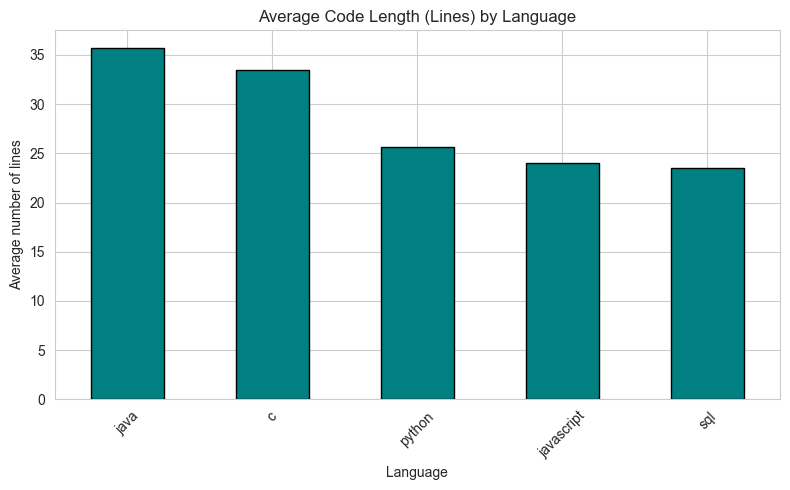

In [6]:
avg_len = df.groupby("language").agg(
    avg_chars=("n_chars", "mean"),
    avg_lines=("n_lines", "mean"),
).round(1)
print(avg_len)

fig, ax = plt.subplots(figsize=(8, 5))
avg_len["avg_lines"].sort_values(ascending=False).plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.set_title("Average Code Length (Lines) by Language")
ax.set_xlabel("Language")
ax.set_ylabel("Average number of lines")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 3B. Box plots and violin plots: code length by model and language

/var/folders/zr/2wb4s69j7kl53vcr3tq54zpw0000gn/T/ipykernel_43403/3992676723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="model", y="n_lines", ax=ax, palette="Set2")


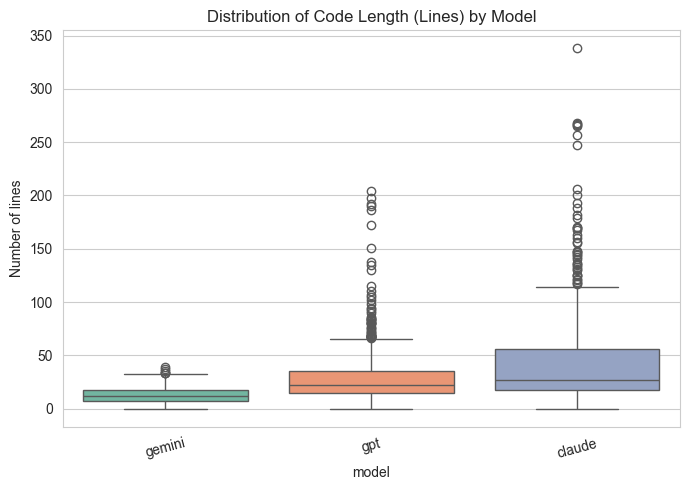

/var/folders/zr/2wb4s69j7kl53vcr3tq54zpw0000gn/T/ipykernel_43403/3992676723.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="language", y="n_lines", palette="Set3")


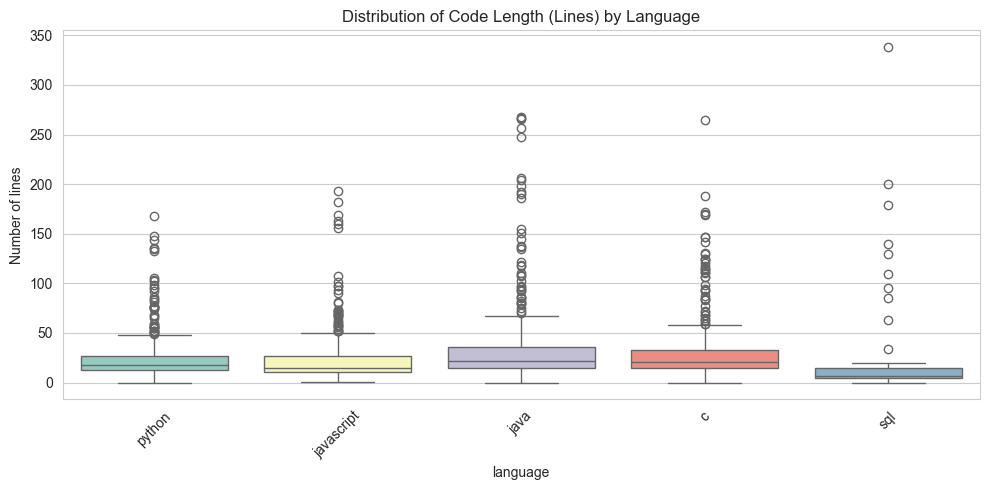

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="model", y="n_lines", ax=ax, palette="Set2")
ax.set_title("Distribution of Code Length (Lines) by Model")
ax.set_ylabel("Number of lines")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="language", y="n_lines", palette="Set3")
plt.title("Distribution of Code Length (Lines) by Language")
plt.ylabel("Number of lines")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4B. Bar chart: most common terms by model

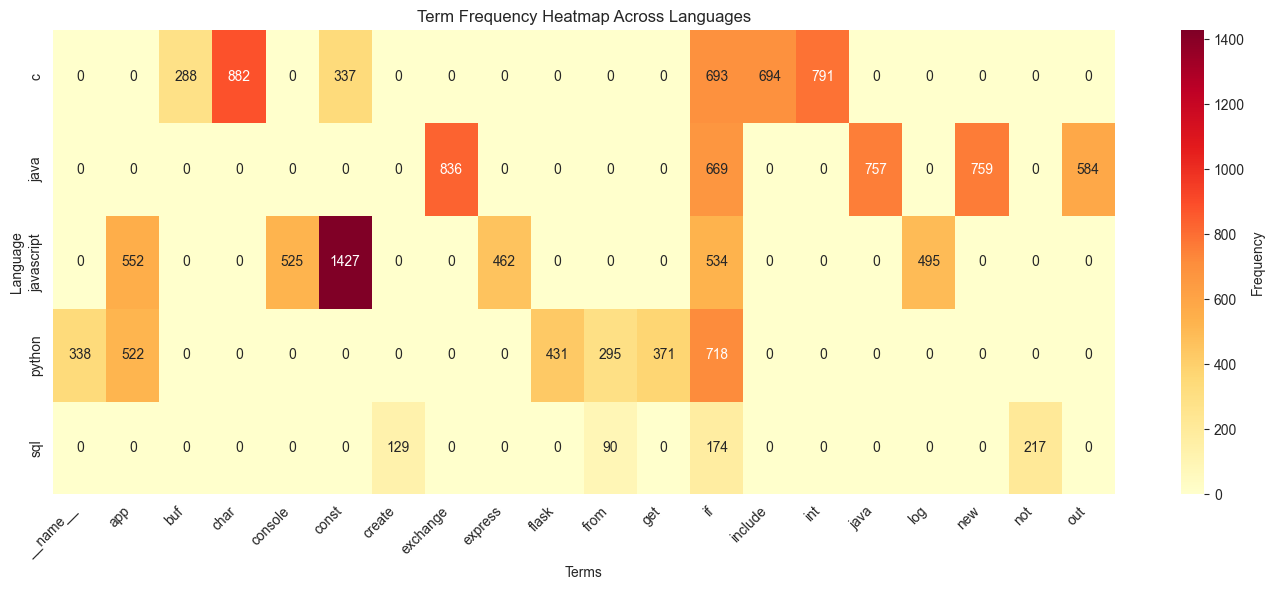

In [20]:
# Create a pivot table: languages as rows, terms as columns
top_terms_all = set()
for lang, terms in lang_term_data.items():
    top_terms_all.update([t for t, _ in terms])

# Build matrix
heatmap_data = []
for lang in sorted(df["language"].unique()):
    term_dict = dict(lang_term_data.get(lang, []))
    row = {"Language": lang}
    for term in sorted(top_terms_all)[:20]:  # Top 20 terms
        row[term] = term_dict.get(term, 0)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index("Language")

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_df, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={"label": "Frequency"})
plt.title("Term Frequency Heatmap Across Languages")
plt.xlabel("Terms")
plt.ylabel("Language")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()